In [1]:
import pandas as pd

df_b = pd.read_csv(
    r"/Users/shiyu/Projects/adhd-segmentation/analysis/B_multivariate.csv"
)

print("Shape:", df_b.shape)

print("\nColumns:")
print(df_b.columns.tolist())

print("\nFirst 10 rows:")
print(df_b.head(10).to_string(index=False))

print("\nUnique values by key columns:")

for col in ["track", "type", "target", "model", "k"]:
    if col in df_b.columns:
        print(f"\n{col}:")
        print(df_b[col].value_counts(dropna=False))

Shape: (612, 18)

Columns:
['variant', 'track', 'target', 'model', 'k', 'n', 'rmse', 'mae', 'rho', 'skill', 'nc_skill', 'skill_over_nc', 'perm_p', 'bmi_sel_frac', 'f1', 'acc', 'bacc', 'q_fdr']

First 10 rows:
variant track     target model  k  n     rmse      mae      rho     skill  nc_skill  skill_over_nc   perm_p  bmi_sel_frac  f1  acc  bacc    q_fdr
   main   reg snap_inatt ridge  5 24 5.634006 4.609606 0.121692 -0.254639 -0.067457      -0.187182      NaN           NaN NaN  NaN   NaN 1.000000
   main   reg snap_inatt ridge 10 24 4.537749 3.569707 0.373394 -0.010513 -0.067457       0.056944      NaN           NaN NaN  NaN   NaN 1.000000
   main   reg snap_inatt   svr  5 24 4.584208 3.493149 0.090613 -0.020859 -0.067457       0.046598      NaN           NaN NaN  NaN   NaN 1.000000
   main   reg snap_inatt   svr 10 24 4.422797 3.350321 0.348005  0.015085 -0.067457       0.082543 0.075785           NaN NaN  NaN   NaN 0.813690
   main   reg snap_inatt    rf  5 24 4.395295 3.364899 0.3283

In [ ]:
##### 先分析regression track的snap_adhd_total
#reg, bin, mulit先选reg
main_reg = df_b[
    (df_b["variant"] == "main") &
    (df_b["track"] == "reg")
].copy()

print("Shape:", main_reg.shape)

print("\nRows per target:")
print(main_reg["target"].value_counts())

print("\nModels:")
print(main_reg["model"].value_counts())

print("\nk values:")
print(main_reg["k"].value_counts())

#只要snap_adhd_total
one_target = main_reg[
    main_reg["target"] == "snap_adhd_total"
]

print(
    one_target[
        [
            "model",
            "k",
            "rmse",
            "mae",
            "rho",
            "skill",
            "nc_skill",
            "skill_over_nc",
            "perm_p",
            "q_fdr"
        ]
    ].to_string(index=False)
)


Shape: (60, 18)

Rows per target:
target
snap_inatt         6
snap_hyper         6
snap_odd           6
snap_adhd_total    6
sdq_hyper          6
sdq_emo            6
sdq_cond           6
sdq_peer           6
sdq_pro            6
sdq_totdiff        6
Name: count, dtype: int64

Models:
model
ridge    20
svr      20
rf       20
Name: count, dtype: int64

k values:
k
5     30
10    30
Name: count, dtype: int64
model  k     rmse      mae       rho     skill  nc_skill  skill_over_nc   perm_p    q_fdr
ridge  5 8.727004 6.968037  0.464125 -0.032090  -0.06723       0.035140      NaN 1.000000
ridge 10 8.525515 6.551778  0.482882 -0.008261  -0.06723       0.058969      NaN 1.000000
  svr  5 9.110789 7.825101 -0.327156 -0.077478  -0.06723      -0.010247      NaN 1.000000
  svr 10 9.602745 8.388781 -0.623340 -0.135658  -0.06723      -0.068428      NaN 1.000000
   rf  5 8.230040 6.430762  0.290950  0.026683  -0.06723       0.093913 0.118576 0.815837
   rf 10 8.025792 6.359153  0.435771  0.050838  -

In [3]:
best_by_target = (
    main_reg
    .sort_values("skill", ascending=False)
    .groupby("target", as_index=False)
    .first()
)

print(
    best_by_target[
        [
            "target",
            "model",
            "k",
            "rmse",
            "mae",
            "rho",
            "skill",
            "nc_skill",
            "skill_over_nc",
            "perm_p",
            "q_fdr"
        ]
    ]
    .sort_values("skill", ascending=False)
    .to_string(index=False)
)


         target model  k     rmse      mae       rho     skill  nc_skill  skill_over_nc   perm_p    q_fdr
        sdq_emo ridge  5 1.428471 1.137659  0.504331  0.163324 -0.060667       0.223991 0.024995 0.566553
     snap_hyper ridge 10 4.007226 3.294419  0.393076  0.055306 -0.069748       0.125053 0.069986 0.813690
snap_adhd_total    rf 10 8.025792 6.359153  0.435771  0.050838 -0.067230       0.118068 0.073385 0.813690
     snap_inatt    rf 10 4.270796 3.304921  0.367266  0.048934 -0.067457       0.116392 0.071186 0.813690
       sdq_cond ridge  5 0.894110 0.682460  0.334533  0.016445 -0.069890       0.086335 0.116777 0.815837
       sdq_peer    rf 10 0.828000 0.620251  0.391236  0.014982 -0.085904       0.100886 0.106179 0.815837
       snap_odd   svr 10 3.717741 2.708565 -0.443022 -0.044882 -0.077777       0.032896      NaN 1.000000
        sdq_pro   svr 10 2.453108 1.989736 -0.105023 -0.094217 -0.033827      -0.060390      NaN 1.000000
      sdq_hyper   svr  5 2.359264 1.980270 -0.

In [4]:
sdq_emo_results = (
    main_reg[
        main_reg["target"] == "sdq_emo"
    ]
    [
        [
            "model",
            "k",
            "rmse",
            "mae",
            "rho",
            "skill",
            "nc_skill",
            "skill_over_nc",
            "perm_p",
            "q_fdr"
        ]
    ]
    .sort_values("skill", ascending=False)
)

print(sdq_emo_results.to_string(index=False))

model  k     rmse      mae      rho     skill  nc_skill  skill_over_nc   perm_p    q_fdr
ridge  5 1.428471 1.137659 0.504331  0.163324 -0.060667       0.223991 0.024995 0.566553
ridge 10 1.443208 1.183651 0.563348  0.154692 -0.060667       0.215359 0.020596 0.530294
  svr 10 1.561400 1.290523 0.322360  0.085466 -0.060667       0.146133 0.033593 0.685303
   rf 10 1.632685 1.315854 0.342927  0.043713 -0.060667       0.104380 0.094581 0.815837
   rf  5 1.692223 1.416178 0.213268  0.008841 -0.060667       0.069508 0.146771 0.815837
  svr  5 1.772333 1.497570 0.083161 -0.038081 -0.060667       0.022586      NaN 1.000000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 修改成你的实际绝对路径
oof = pd.read_csv(
    r"/Users/shiyu/Projects/adhd-segmentation/analysis/B_oof_predictions.csv"
)

# 只保留 main / regression / sdq_emo / Ridge
sdq_emo_ridge = oof[
    (oof["variant"] == "main") &
    (oof["track"] == "reg") &
    (oof["target"] == "sdq_emo") &
    (oof["model"] == "ridge") &
    (oof["k"].isin([5, 10]))
].copy()

print("Filtered shape:", sdq_emo_ridge.shape)
print(sdq_emo_ridge.groupby("k")["subject"].nunique())

Filtered shape: (48, 8)
k
5     24
10    24
Name: subject, dtype: int64


In [10]:
import numpy as np

def exact_b_track_analysis(df_one_k):
    result = df_one_k.copy()

    # B轨实际使用的常数均值基线
    baseline_value = result["y_true"].mean()
    result["baseline_pred"] = baseline_value

    result["model_sq_error"] = (
        result["y_true"] - result["y_pred"]
    ) ** 2

    result["baseline_sq_error"] = (
        result["y_true"] - result["baseline_pred"]
    ) ** 2

    result["sq_error_improvement"] = (
        result["baseline_sq_error"]
        - result["model_sq_error"]
    )

    model_rmse = np.sqrt(result["model_sq_error"].mean())
    baseline_rmse = np.sqrt(result["baseline_sq_error"].mean())

    skill = 1 - model_rmse / baseline_rmse

    return result, model_rmse, baseline_rmse, skill


corrected_results = {}

for k in [5, 10]:
    one_k = sdq_emo_ridge[
        sdq_emo_ridge["k"] == k
    ].copy()

    result, model_rmse, baseline_rmse, skill = (
        exact_b_track_analysis(one_k)
    )

    corrected_results[k] = result

    print(f"\n===== Ridge k={k} =====")
    print(f"Model RMSE:    {model_rmse:.6f}")
    print(f"Baseline RMSE: {baseline_rmse:.6f}")
    print(f"Skill:         {skill:.6f}")
    print(
        "Subjects improved:",
        f'{(result["sq_error_improvement"] > 0).sum()}/24'
    )

    print("\nLargest positive contributions:")
    print(
        result[
            ["subject", "y_true", "y_pred",
             "sq_error_improvement"]
        ]
        .nlargest(5, "sq_error_improvement")
        .round(3)
        .to_string(index=False)
    )

    print("\nLargest negative contributions:")
    print(
        result[
            ["subject", "y_true", "y_pred",
             "sq_error_improvement"]
        ]
        .nsmallest(5, "sq_error_improvement")
        .round(3)
        .to_string(index=False)
    )


===== Ridge k=5 =====
Model RMSE:    1.428471
Baseline RMSE: 1.707317
Skill:         0.163324
Subjects improved: 14/24

Largest positive contributions:
subject  y_true  y_pred  sq_error_improvement
    H47     5.0   4.275                 9.768
     Z8     4.0   3.444                 4.568
    W53     5.0   2.389                 3.476
    Z39     0.0   0.266                 3.139
    C43     0.0   0.700                 2.719

Largest negative contributions:
subject  y_true  y_pred  sq_error_improvement
    X31     0.0   2.717                -4.174
     Z7     3.0   1.230                -1.673
    H48     4.0   1.478                -1.483
    W23     0.0   2.005                -0.812
     H2     4.0   1.628                -0.751

===== Ridge k=10 =====
Model RMSE:    1.443208
Baseline RMSE: 1.707317
Skill:         0.154692
Subjects improved: 15/24

Largest positive contributions:
subject  y_true  y_pred  sq_error_improvement
    H47     5.0   3.965                 9.223
     Z8     4.0 

In [11]:
for k, result in results.items():
    improved = (result["sq_error_improvement"] > 0).sum()
    worsened = (result["sq_error_improvement"] < 0).sum()

    total_baseline_sse = result["baseline_sq_error"].sum()
    total_model_sse = result["model_sq_error"].sum()

    r2_like = 1 - total_model_sse / total_baseline_sse

    print(f"\n===== Ridge k={k} =====")
    print(f"Subjects improved over baseline: {improved}/24")
    print(f"Subjects worse than baseline:    {worsened}/24")
    print(f"Baseline SSE: {total_baseline_sse:.4f}")
    print(f"Model SSE:    {total_model_sse:.4f}")
    print(f"SSE-based improvement: {r2_like:.4f}")


===== Ridge k=5 =====
Subjects improved over baseline: 15/24
Subjects worse than baseline:    9/24
Baseline SSE: 76.1739
Model SSE:    48.9727
SSE-based improvement: 0.3571

===== Ridge k=10 =====
Subjects improved over baseline: 15/24
Subjects worse than baseline:    9/24
Baseline SSE: 76.1739
Model SSE:    49.9884
SSE-based improvement: 0.3438


In [12]:
for k, result in results.items():
    table = result[
        [
            "subject",
            "y_true",
            "y_pred",
            "baseline_pred",
            "model_abs_error",
            "baseline_abs_error",
            "sq_error_improvement"
        ]
    ].sort_values(
        "sq_error_improvement",
        ascending=False
    )

    print(f"\n===== Subject contributions: Ridge k={k} =====")
    print(table.round(3).to_string(index=False))


===== Subject contributions: Ridge k=5 =====
subject  y_true  y_pred  baseline_pred  model_abs_error  baseline_abs_error  sq_error_improvement
    H47     5.0   4.275          1.652            0.725               3.348                10.682
     Z8     4.0   3.444          1.696            0.556               2.304                 5.001
    W53     5.0   2.389          1.652            2.611               3.348                 4.390
    Z39     0.0   0.266          1.870            0.266               1.870                 3.425
    C43     0.0   0.700          1.870            0.700               1.870                 3.005
    L16     0.0   0.826          1.870            0.826               1.870                 2.813
    H45     0.0   1.335          1.870            1.335               1.870                 1.714
    J34     0.0   1.336          1.870            1.336               1.870                 1.710
    Y52     1.0   1.194          1.826            0.194               0.

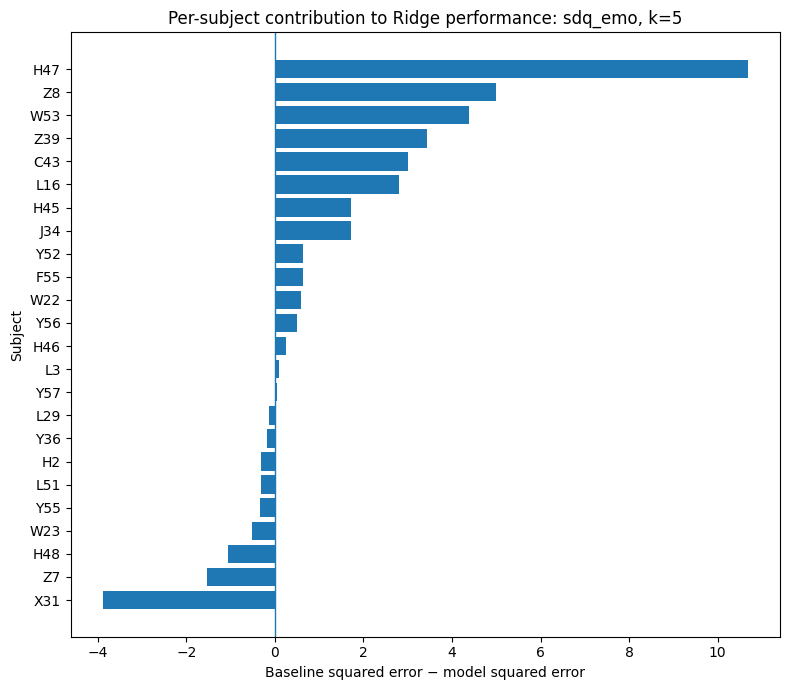

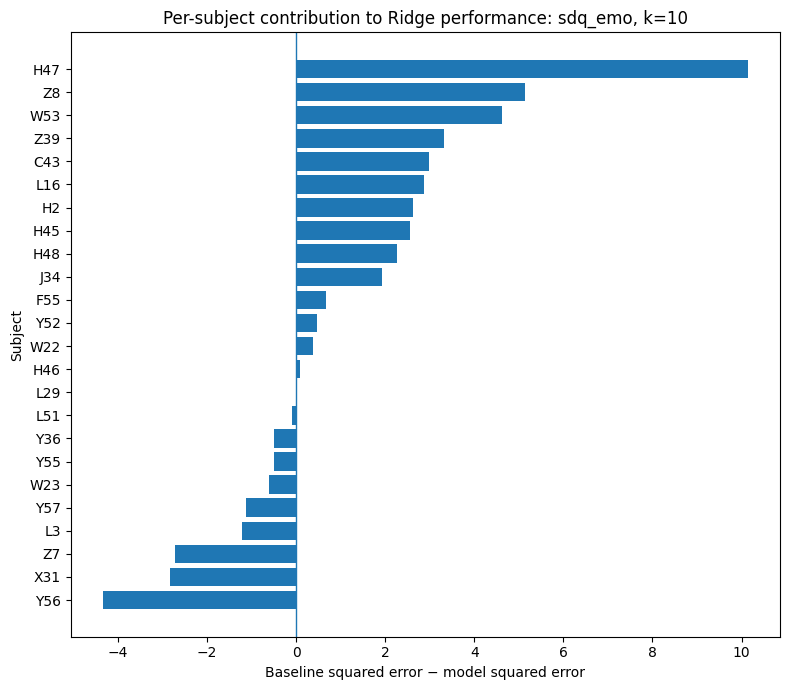

In [13]:
for k, result in results.items():
    plot_df = result.sort_values(
        "sq_error_improvement",
        ascending=True
    )

    plt.figure(figsize=(8, 7))

    plt.barh(
        plot_df["subject"],
        plot_df["sq_error_improvement"]
    )

    plt.axvline(0, linewidth=1)

    plt.xlabel(
        "Baseline squared error − model squared error"
    )
    plt.ylabel("Subject")
    plt.title(
        f"Per-subject contribution to Ridge performance: "
        f"sdq_emo, k={k}"
    )

    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import pandas as pd

def deletion_metric_sensitivity(df_one_k):
    rows = []

    for removed_subject in df_one_k["subject"]:
        reduced = df_one_k[
            df_one_k["subject"] != removed_subject
        ].copy()

        model_rmse = np.sqrt(
            np.mean(
                (reduced["y_true"] - reduced["y_pred"]) ** 2
            )
        )

        # 在剩余23人中重新计算均值基线
        baseline_mean = reduced["y_true"].mean()

        baseline_rmse = np.sqrt(
            np.mean(
                (reduced["y_true"] - baseline_mean) ** 2
            )
        )

        skill = 1 - model_rmse / baseline_rmse

        rows.append({
            "removed_subject": removed_subject,
            "n_remaining": len(reduced),
            "model_rmse": model_rmse,
            "baseline_rmse": baseline_rmse,
            "skill_after_removal": skill
        })

    return pd.DataFrame(rows)


for k in [5, 10]:
    one_k = sdq_emo_ridge[
        sdq_emo_ridge["k"] == k
    ].copy()

    sensitivity = deletion_metric_sensitivity(one_k)

    print(f"\n===== Ridge k={k} =====")
    print(
        sensitivity[
            ["removed_subject", "skill_after_removal"]
        ]
        .sort_values("skill_after_removal")
        .round(4)
        .to_string(index=False)
    )

    print("\nSummary:")
    print(
        sensitivity["skill_after_removal"]
        .describe()
        .round(4)
    )


===== Ridge k=5 =====
removed_subject  skill_after_removal
            H47               0.0955
             Z8               0.1339
            Z39               0.1432
            C43               0.1469
            L16               0.1485
            W53               0.1563
            H45               0.1583
            J34               0.1583
            Y52               0.1597
            F55               0.1597
            W22               0.1601
            Y57               0.1631
            H46               0.1632
            L29               0.1647
            Y36               0.1650
            L51               0.1662
            Y55               0.1663
             L3               0.1729
            Y56               0.1749
            W23               0.1785
             Z7               0.1816
             H2               0.1826
            H48               0.1895
            X31               0.2098

Summary:
count    24.0000
mean      0.1624
std     

Pearson correlation:  0.9611
Spearman correlation: 0.8739
Mean absolute difference: 0.3172
Maximum absolute difference: 1.0272

Largest prediction differences:
subject  y_true  pred_k5  pred_k10  prediction_difference  abs_difference
    Y57     2.0    1.950     0.923                 -1.027           1.027
    Y56     4.0    6.194     7.106                  0.912           0.912
    H48     4.0    1.478     2.255                  0.777           0.777
     H2     4.0    1.628     2.363                  0.736           0.736
    Z39     0.0    0.266    -0.411                 -0.677           0.677
    H45     0.0    1.335     0.973                 -0.362           0.362
     L3     0.0    1.847     2.172                  0.325           0.325
    H47     5.0    4.275     3.965                 -0.309           0.309


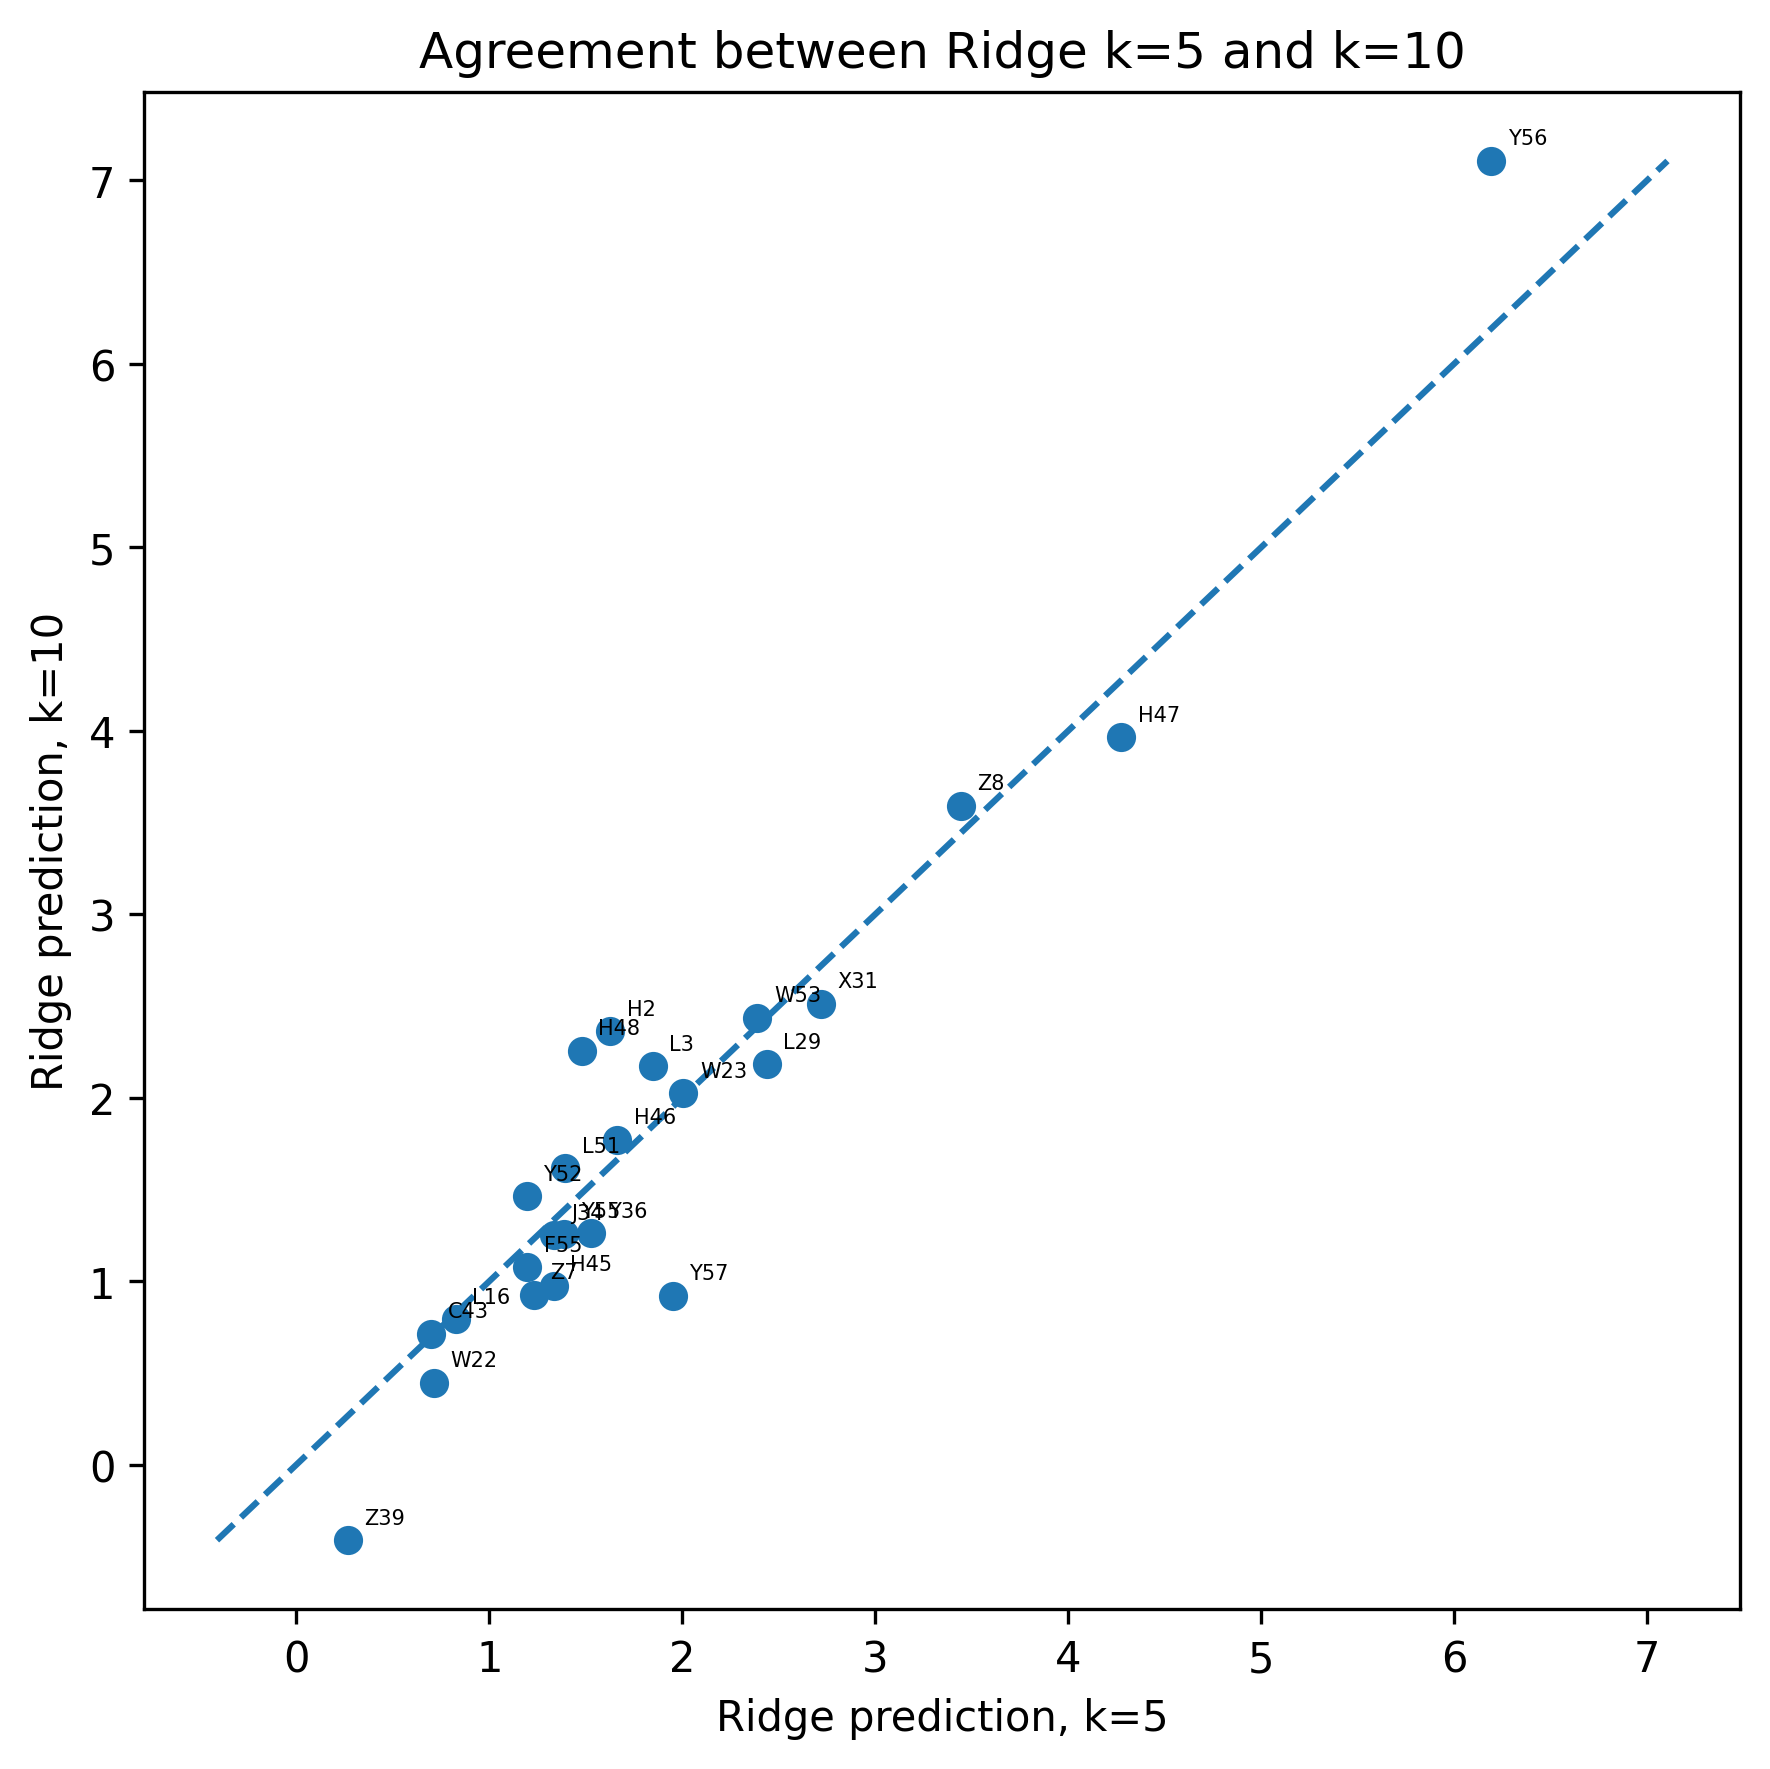

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt

k5 = sdq_emo_ridge[
    sdq_emo_ridge["k"] == 5
][
    ["subject", "y_true", "y_pred"]
].rename(
    columns={"y_pred": "pred_k5"}
)

k10 = sdq_emo_ridge[
    sdq_emo_ridge["k"] == 10
][
    ["subject", "y_pred"]
].rename(
    columns={"y_pred": "pred_k10"}
)

compare = k5.merge(
    k10,
    on="subject",
    how="inner"
)

pearson_r, pearson_p = pearsonr(
    compare["pred_k5"],
    compare["pred_k10"]
)

spearman_rho, spearman_p = spearmanr(
    compare["pred_k5"],
    compare["pred_k10"]
)

compare["prediction_difference"] = (
    compare["pred_k10"] - compare["pred_k5"]
)

print(f"Pearson correlation:  {pearson_r:.4f}")
print(f"Spearman correlation: {spearman_rho:.4f}")
print(
    "Mean absolute difference:",
    f'{compare["prediction_difference"].abs().mean():.4f}'
)
print(
    "Maximum absolute difference:",
    f'{compare["prediction_difference"].abs().max():.4f}'
)

print("\nLargest prediction differences:")
print(
    compare[
        [
            "subject",
            "y_true",
            "pred_k5",
            "pred_k10",
            "prediction_difference"
        ]
    ]
    .assign(
        abs_difference=lambda x:
            x["prediction_difference"].abs()
    )
    .sort_values("abs_difference", ascending=False)
    .head(8)
    .round(3)
    .to_string(index=False)
)

plt.figure(figsize=(6, 6)
           ,dpi=300
)

plt.scatter(
    compare["pred_k5"],
    compare["pred_k10"]
)

for _, row in compare.iterrows():
    plt.annotate(
        row["subject"],
        (row["pred_k5"], row["pred_k10"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=5
    )

lower = min(
    compare["pred_k5"].min(),
    compare["pred_k10"].min()
)

upper = max(
    compare["pred_k5"].max(),
    compare["pred_k10"].max()
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)

plt.xlabel("Ridge prediction, k=5")
plt.ylabel("Ridge prediction, k=10")
plt.title("Agreement between Ridge k=5 and k=10")

plt.tight_layout()
plt.show()

In [21]:
##### B轨 main 的全局总览，把 reg、bin、multi 三个 track 放在一张汇总表中。

import pandas as pd
import numpy as np

# 如果当前 notebook 中已经有 df_b，可跳过这一行
# df_b = pd.read_csv(r"/你的路径/B_multivariate.csv")

main_b = df_b[
    df_b["variant"] == "main"
].copy()

print("Main-arm shape:", main_b.shape)
print(main_b["track"].value_counts())

#汇总表
def summarize_track(track_df, track_name):
    track_df = track_df.copy()

    if track_name == "reg":
        metric = "skill"
        track_df["above_baseline"] = track_df["skill"] > 0
    else:
        metric = "bacc"
        track_df["above_baseline"] = track_df["bacc"] > 0.5

    best_idx = track_df[metric].idxmax()
    best = track_df.loc[best_idx]

    valid_p = track_df["perm_p"].dropna()
    valid_q = track_df["q_fdr"].dropna()

    return {
        "track": track_name,
        "combinations": len(track_df),
        "targets": track_df["target"].nunique(),
        "above_baseline": int(
            track_df["above_baseline"].sum()
        ),
        "targets_above_baseline": int(
            track_df.loc[
                track_df["above_baseline"], "target"
            ].nunique()
        ),
        "permutation_tested": int(
            track_df["perm_p"].notna().sum()
        ),
        "best_target": best["target"],
        "best_model": best["model"],
        "best_k": int(best["k"]),
        "best_metric": metric,
        "best_metric_value": best[metric],
        "best_perm_p": best["perm_p"],
        "best_q_fdr": best["q_fdr"],
        "minimum_perm_p": (
            valid_p.min() if len(valid_p) else np.nan
        ),
        "minimum_q_fdr": (
            valid_q.min() if len(valid_q) else np.nan
        ),
        "q_below_0.05": int(
            (track_df["q_fdr"] < 0.05).sum()
        )
    }


summary = pd.DataFrame([
    summarize_track(
        main_b[main_b["track"] == track],
        track
    )
    for track in ["reg", "bin", "multi"]
])

print(
    summary.round(4).to_string(index=False)
)

Main-arm shape: (204, 18)
track
multi    84
reg      60
bin      60
Name: count, dtype: int64
track  combinations  targets  above_baseline  targets_above_baseline  permutation_tested       best_target best_model  best_k best_metric  best_metric_value  best_perm_p  best_q_fdr  minimum_perm_p  minimum_q_fdr  q_below_0.05
  reg            60       10              14                       6                  14           sdq_emo      ridge       5       skill             0.1633       0.0250      0.5666          0.0206         0.5303             0
  bin            60       10              28                       8                  28 sdq_totdiff__qbin         rf       5        bacc             0.8222       0.0130      0.5303          0.0130         0.5303             0
multi            84       14               5                       2                  28     sdq_emo__qter      logit       5        bacc             0.6270       0.0156      0.5303          0.0082         0.5303             

In [22]:
audit_rows = []

for track in ["reg", "bin", "multi"]:
    temp = main_b[
        main_b["track"] == track
    ].copy()

    if track == "reg":
        eligible = temp["skill"] > 0
    else:
        eligible = temp["bacc"] > 0.5

    tested = temp["perm_p"].notna()

    audit_rows.append({
        "track": track,
        "eligible_for_permutation": int(eligible.sum()),
        "actually_permutation_tested": int(tested.sum()),
        "eligible_but_not_tested": int(
            (eligible & ~tested).sum()
        ),
        "tested_but_not_eligible": int(
            (~eligible & tested).sum()
        )
    })

audit = pd.DataFrame(audit_rows)

print("\n===== Permutation audit =====")
print(audit.to_string(index=False))


===== Permutation audit =====
track  eligible_for_permutation  actually_permutation_tested  eligible_but_not_tested  tested_but_not_eligible
  reg                        14                           14                        0                        0
  bin                        28                           28                        0                        0
multi                         5                           28                        0                       23


In [23]:
for track, metric in [
    ("reg", "skill"),
    ("bin", "bacc"),
    ("multi", "bacc")
]:
    top = (
        main_b[
            main_b["track"] == track
        ]
        .sort_values(metric, ascending=False)
        .head(5)
    )

    columns = [
        "target",
        "model",
        "k",
        metric,
        "perm_p",
        "q_fdr"
    ]

    if track == "reg":
        columns.insert(4, "skill_over_nc")
    else:
        columns.insert(4, "f1")
        columns.insert(5, "acc")

    print(f"\n===== Top 5: {track} =====")
    print(
        top[columns]
        .round(4)
        .to_string(index=False)
    )


===== Top 5: reg =====
         target model  k  skill  skill_over_nc  perm_p  q_fdr
        sdq_emo ridge  5 0.1633         0.2240  0.0250 0.5666
        sdq_emo ridge 10 0.1547         0.2154  0.0206 0.5303
        sdq_emo   svr 10 0.0855         0.1461  0.0336 0.6853
     snap_hyper ridge 10 0.0553         0.1251  0.0700 0.8137
snap_adhd_total    rf 10 0.0508         0.1181  0.0734 0.8137

===== Top 5: bin =====
           target model  k   bacc     f1    acc  perm_p  q_fdr
sdq_totdiff__qbin    rf  5 0.8222 0.8222 0.8333  0.0130 0.5303
sdq_totdiff__qbin   svm  5 0.7667 0.7723 0.7917  0.0426 0.7614
sdq_totdiff__qbin logit  5 0.6889 0.6975 0.7500  0.0802 0.8158
   snap_odd__qbin   svm 10 0.6778 0.6812 0.7083  0.1094 0.8158
   sdq_cond__qbin   svm 10 0.6562 0.6606 0.7083  0.1394 0.8158

===== Top 5: multi =====
           target model  k   bacc     f1    acc  perm_p  q_fdr
    sdq_emo__qter   svm  5 0.6270 0.6336 0.6250  0.0120 0.5303
    sdq_emo__qter logit  5 0.6270 0.6336 0.6250  0

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    f1_score
)

# 已经读过可跳过
# oof = pd.read_csv(r"/你的路径/B_oof_predictions.csv")

top_bin = oof[
    (oof["variant"] == "main") &
    (oof["track"] == "bin") &
    (oof["target"] == "sdq_totdiff__qbin") &
    (oof["model"] == "rf") &
    (oof["k"] == 5)
].copy()

print("Shape:", top_bin.shape)
print("\nClass counts:")
print(top_bin["y_true"].value_counts().sort_index())

print("\nPrediction counts:")
print(top_bin["y_pred"].value_counts().sort_index())

Shape: (24, 8)

Class counts:
y_true
0.0    15
1.0     9
Name: count, dtype: int64

Prediction counts:
y_pred
0.0    15
1.0     9
Name: count, dtype: int64


Shape: (24, 8)

Class counts:
y_true
0    15
1     9
Name: count, dtype: int64

Prediction counts:
y_pred
0    15
1     9
Name: count, dtype: int64

Confusion matrix:
[[13  2]
 [ 2  7]]

Balanced accuracy: 0.8222
Accuracy:          0.8333
Macro F1:          0.8222

Classification report:
              precision    recall  f1-score   support

           0     0.8667    0.8667    0.8667        15
           1     0.7778    0.7778    0.7778         9

    accuracy                         0.8333        24
   macro avg     0.8222    0.8222    0.8222        24
weighted avg     0.8333    0.8333    0.8333        24



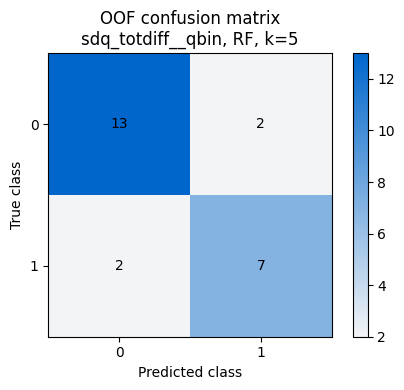


Misclassified subjects:
subject  y_true  y_pred
    W22     0.0     1.0
    X31     0.0     1.0
     H2     1.0     0.0
    L16     1.0     0.0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    f1_score
)

top_bin = oof[
    (oof["variant"] == "main") &
    (oof["track"] == "bin") &
    (oof["target"] == "sdq_totdiff__qbin") &
    (oof["model"] == "rf") &
    (oof["k"] == 5)
].copy()

y_true = top_bin["y_true"].astype(int)
y_pred = top_bin["y_pred"].astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Shape:", top_bin.shape)

print("\nClass counts:")
print(y_true.value_counts().sort_index())

print("\nPrediction counts:")
print(y_pred.value_counts().sort_index())

print("\nConfusion matrix:")
print(cm)

print(
    f"\nBalanced accuracy: "
    f"{balanced_accuracy_score(y_true, y_pred):.4f}"
)
print(
    f"Accuracy:          "
    f"{accuracy_score(y_true, y_pred):.4f}"
)
print(
    f"Macro F1:          "
    f"{f1_score(y_true, y_pred, average='macro'):.4f}"
)

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        digits=4,
        zero_division=0
    )
)

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#F3F4F6", "#0066CC"]
)

fig, ax = plt.subplots(figsize=(5, 4))

image = ax.imshow(
    cm,
    cmap=custom_cmap
)


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(
    "OOF confusion matrix\n"
    "sdq_totdiff__qbin, RF, k=5"
)

plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

top_bin["correct"] = y_true == y_pred

print("\nMisclassified subjects:")
print(
    top_bin.loc[
        ~top_bin["correct"],
        ["subject", "y_true", "y_pred"]
    ]
    .sort_values(["y_true", "subject"])
    .to_string(index=False)
)

In [35]:
sdq_totdiff_bin = (
    main_b[
        (main_b["track"] == "bin") &
        (main_b["target"] == "sdq_totdiff__qbin")
    ]
    [
        [
            "model",
            "k",
            "f1",
            "acc",
            "bacc",
            "perm_p",
            "q_fdr"
        ]
    ]
    .sort_values("bacc", ascending=False)
)

print(sdq_totdiff_bin.round(4).to_string(index=False))

model  k     f1    acc   bacc  perm_p  q_fdr
   rf  5 0.8222 0.8333 0.8222  0.0130 0.5303
  svm  5 0.7723 0.7917 0.7667  0.0426 0.7614
logit  5 0.6975 0.7500 0.6889  0.0802 0.8158
   rf 10 0.5901 0.6250 0.5889  0.2410 0.9223
logit 10 0.4080 0.4583 0.4111     NaN 1.0000
  svm 10 0.3778 0.4167 0.3778     NaN 1.0000


In [36]:
from functools import reduce

models = ["rf", "svm", "logit"]
tables = []

for model in models:
    temp = oof[
        (oof["variant"] == "main") &
        (oof["track"] == "bin") &
        (oof["target"] == "sdq_totdiff__qbin") &
        (oof["model"] == model) &
        (oof["k"] == 5)
    ][["subject", "y_true", "y_pred"]].copy()

    temp = temp.rename(
        columns={"y_pred": f"pred_{model}"}
    )

    if model != "rf":
        temp = temp.drop(columns="y_true")

    tables.append(temp)

compare_k5 = reduce(
    lambda left, right:
        left.merge(right, on="subject", how="inner"),
    tables
)

for model in models:
    compare_k5[f"correct_{model}"] = (
        compare_k5[f"pred_{model}"].astype(int)
        == compare_k5["y_true"].astype(int)
    )

compare_k5["n_models_correct"] = compare_k5[
    [f"correct_{m}" for m in models]
].sum(axis=1)

print(
    compare_k5.sort_values(
        ["n_models_correct", "subject"]
    ).to_string(index=False)
)

print("\nAgreement summary:")
print(
    compare_k5["n_models_correct"]
    .value_counts()
    .sort_index()
)

subject  y_true  pred_rf  pred_svm  pred_logit  correct_rf  correct_svm  correct_logit  n_models_correct
     H2     1.0      0.0       0.0         0.0       False        False          False                 0
    L16     1.0      0.0       0.0         0.0       False        False          False                 0
    X31     0.0      1.0       1.0         1.0       False        False          False                 0
    Y36     1.0      1.0       0.0         0.0        True        False          False                 1
    H46     1.0      1.0       1.0         0.0        True         True          False                 2
    W22     0.0      1.0       0.0         0.0       False         True           True                 2
    W53     1.0      1.0       1.0         0.0        True         True          False                 2
     Z8     0.0      0.0       1.0         0.0        True        False           True                 2
    C43     0.0      0.0       0.0         0.0        T

In [41]:
import pandas as pd

P = pd.read_csv("/Users/shiyu/Projects/adhd-segmentation/analysis/B_oof_predictions.csv")

hard_subjects = ["H2", "L16", "X31"]

hard_reg = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff' "
    "and subject in @hard_subjects"
).copy()

hard_reg["error"] = hard_reg["y_pred"] - hard_reg["y_true"]
hard_reg["abs_error"] = hard_reg["error"].abs()

print(
    hard_reg[
        [
            "subject",
            "model",
            "k",
            "y_true",
            "y_pred",
            "error",
            "abs_error"
        ]
    ]
    .sort_values(["subject", "model", "k"])
    .round(2)
    .to_string(index=False)
)

subject model  k  y_true  y_pred  error  abs_error
     H2    rf  5    12.0    7.58  -4.42       4.42
     H2    rf 10    12.0    8.56  -3.44       3.44
     H2 ridge  5    12.0    8.77  -3.23       3.23
     H2 ridge 10    12.0    9.81  -2.19       2.19
     H2   svr  5    12.0    8.08  -3.92       3.92
     H2   svr 10    12.0    8.81  -3.19       3.19
    L16    rf  5    10.0    9.22  -0.78       0.78
    L16    rf 10    10.0    8.35  -1.65       1.65
    L16 ridge  5    10.0    8.60  -1.40       1.40
    L16 ridge 10    10.0    7.76  -2.24       2.24
    L16   svr  5    10.0    9.27  -0.73       0.73
    L16   svr 10    10.0    8.33  -1.67       1.67
    X31    rf  5     3.0   11.52   8.52       8.52
    X31    rf 10     3.0   11.03   8.03       8.03
    X31 ridge  5     3.0   11.41   8.41       8.41
    X31 ridge 10     3.0   10.96   7.96       7.96
    X31   svr  5     3.0   10.52   7.52       7.52
    X31   svr 10     3.0    9.96   6.96       6.96


In [42]:
reg_sdq = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff'"
).copy()

reg_sdq["error"] = reg_sdq["y_pred"] - reg_sdq["y_true"]
reg_sdq["abs_error"] = reg_sdq["error"].abs()

subject_error = (
    reg_sdq
    .groupby("subject")
    .agg(
        y_true=("y_true", "first"),
        mean_prediction=("y_pred", "mean"),
        min_prediction=("y_pred", "min"),
        max_prediction=("y_pred", "max"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max")
    )
    .sort_values("mean_abs_error", ascending=False)
    .reset_index()
)

print(
    subject_error
    .round(2)
    .to_string(index=False)
)

subject  y_true  mean_prediction  min_prediction  max_prediction  mean_error  mean_abs_error  max_abs_error
    X31     3.0            10.90            9.96           11.52        7.90            7.90           8.52
    W53    16.0             8.40            7.77            8.95       -7.60            7.60           8.23
    W23     5.0            11.06            9.85           11.79        6.06            6.06           6.79
    Y36    14.0             8.22            7.88            8.77       -5.78            5.78           6.12
    W22     4.0             9.61            8.85           10.44        5.61            5.61           6.44
    Y56    14.0             8.84            8.41            9.27       -5.16            5.16           5.59
     L3     7.0            11.49            9.50           12.73        4.49            4.49           5.73
    Y55     6.0            10.18            9.92           10.62        4.18            4.18           4.62
    Y52     7.0            1

In [43]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

x = subject_error["y_true"].to_numpy()
y = subject_error["mean_prediction"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print(f"True-score range:       {x.min():.2f} to {x.max():.2f}")
print(f"Prediction range:       {y.min():.2f} to {y.max():.2f}")
print(f"True-score SD:          {x.std(ddof=1):.2f}")
print(f"Prediction SD:          {y.std(ddof=1):.2f}")
print(f"Regression slope:       {slope:.3f}")
print(f"Regression intercept:   {intercept:.3f}")
print(f"Pearson r:              {pearson_r:.3f}, p={pearson_p:.4f}")
print(f"Spearman rho:           {spearman_rho:.3f}, p={spearman_p:.4f}")

True-score range:       3.00 to 16.00
Prediction range:       5.89 to 11.49
True-score SD:          3.25
Prediction SD:          1.41
Regression slope:       -0.196
Regression intercept:   10.760
Pearson r:              -0.449, p=0.0278
Spearman rho:           -0.538, p=0.0067


In [44]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

reg_sdq = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff'"
).copy()

rows = []

for (model, k), g in reg_sdq.groupby(["model", "k"]):
    y_true = g["y_true"].to_numpy()
    y_pred = g["y_pred"].to_numpy()

    slope, intercept = np.polyfit(y_true, y_pred, 1)

    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_rho, spearman_p = spearmanr(y_true, y_pred)

    rmse_model = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    baseline_pred = np.repeat(y_true.mean(), len(y_true))
    rmse_baseline = mean_squared_error(
        y_true,
        baseline_pred
    ) ** 0.5

    skill = 1 - rmse_model / rmse_baseline

    rows.append({
        "model": model,
        "k": k,
        "slope": slope,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "rmse": rmse_model,
        "skill": skill
    })

model_direction = pd.DataFrame(rows).sort_values(
    ["spearman_rho", "pearson_r"]
)

print(
    model_direction
    .round(4)
    .to_string(index=False)
)

model  k   slope  pearson_r  pearson_p  spearman_rho  spearman_p   rmse   skill
  svr  5 -0.1417    -0.5772     0.0031       -0.6372      0.0008 3.6943 -0.1619
  svr 10 -0.1257    -0.5885     0.0025       -0.6012      0.0019 3.6247 -0.1400
   rf 10 -0.2386    -0.4898     0.0151       -0.5801      0.0030 4.1667 -0.3105
   rf  5 -0.2587    -0.4952     0.0139       -0.5506      0.0053 4.2668 -0.3420
ridge 10 -0.1972    -0.2812     0.1831       -0.3923      0.0580 4.3670 -0.3735
ridge  5 -0.2115    -0.2938     0.1634       -0.3633      0.0810 4.4307 -0.3935


In [45]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

reg_sdq = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff'"
).copy()

truth = (
    reg_sdq[["subject", "y_true"]]
    .drop_duplicates("subject")
    .copy()
)

n = len(truth)
global_mean = truth["y_true"].mean()

truth["loo_train_mean"] = (
    n * global_mean - truth["y_true"]
) / (n - 1)

baseline_slope = np.polyfit(
    truth["y_true"],
    truth["loo_train_mean"],
    1
)[0]

print(f"n: {n}")
print(f"Global mean: {global_mean:.3f}")
print(f"LOO-mean expected slope: {-1/(n-1):.4f}")
print(f"LOO-mean observed slope: {baseline_slope:.4f}")

rows = []

for (model, k), g in reg_sdq.groupby(["model", "k"]):
    g = g.merge(
        truth[["subject", "loo_train_mean"]],
        on="subject",
        how="left"
    )

    # 模型相对于该折训练均值的偏移
    g["prediction_delta"] = (
        g["y_pred"] - g["loo_train_mean"]
    )

    slope_raw = np.polyfit(
        g["y_true"], g["y_pred"], 1
    )[0]

    slope_delta = np.polyfit(
        g["y_true"], g["prediction_delta"], 1
    )[0]

    r_delta, _ = pearsonr(
        g["y_true"], g["prediction_delta"]
    )

    rho_delta, _ = spearmanr(
        g["y_true"], g["prediction_delta"]
    )

    rows.append({
        "model": model,
        "k": k,
        "raw_slope": slope_raw,
        "delta_slope": slope_delta,
        "delta_pearson_r": r_delta,
        "delta_spearman_rho": rho_delta
    })

delta_audit = pd.DataFrame(rows)

print(
    delta_audit
    .sort_values(["model", "k"])
    .round(4)
    .to_string(index=False)
)

n: 24
Global mean: 8.875
LOO-mean expected slope: -0.0435
LOO-mean observed slope: -0.0435
model  k  raw_slope  delta_slope  delta_pearson_r  delta_spearman_rho
   rf  5    -0.2587      -0.2152          -0.4284             -0.4956
   rf 10    -0.2386      -0.1951          -0.4174             -0.4948
ridge  5    -0.2115      -0.1681          -0.2373             -0.3426
ridge 10    -0.1972      -0.1537          -0.2227             -0.3356
  svr  5    -0.1417      -0.0982          -0.4400             -0.5018
  svr 10    -0.1257      -0.0823          -0.4299             -0.4741


In [47]:
import numpy as np
import pandas as pd

targets = (
    pd.read_csv("/Users/shiyu/Projects/adhd-segmentation/analysis/targets.csv")
    [["subject", "sdq_totdiff"]]
    .drop_duplicates("subject")
)

reg_sdq = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff'"
).copy()

audit = reg_sdq.merge(
    targets,
    on="subject",
    how="left",
    validate="many_to_one"
)

audit["target_match"] = np.isclose(
    audit["y_true"],
    audit["sdq_totdiff"],
    equal_nan=False
)

print("Rows:", len(audit))
print("Unique subjects:", audit["subject"].nunique())
print("Missing target values:", audit["sdq_totdiff"].isna().sum())
print("Mismatched y_true values:", (~audit["target_match"]).sum())

print("\nRows and subjects per configuration:")
print(
    audit.groupby(["model", "k"])
    .agg(
        rows=("subject", "size"),
        subjects=("subject", "nunique"),
        y_true_values=("y_true", "count")
    )
)

print("\nMismatches:")
print(
    audit.loc[
        ~audit["target_match"],
        ["model", "k", "subject", "y_true", "sdq_totdiff"]
    ].to_string(index=False)
)

Rows: 144
Unique subjects: 24
Missing target values: 0
Mismatched y_true values: 0

Rows and subjects per configuration:
          rows  subjects  y_true_values
model k                                
rf    5     24        24             24
      10    24        24             24
ridge 5     24        24             24
      10    24        24             24
svr   5     24        24             24
      10    24        24             24

Mismatches:
Empty DataFrame
Columns: [model, k, subject, y_true, sdq_totdiff]
Index: []


In [48]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

reg_sdq = P.query(
    "variant == 'main' "
    "and track == 'reg' "
    "and target == 'sdq_totdiff'"
).copy()

scenarios = {
    "all_24": [],
    "drop_X31": ["X31"],
    "drop_W53": ["W53"],
    "drop_both": ["X31", "W53"]
}

rows = []

for (model, k), g in reg_sdq.groupby(["model", "k"]):

    for scenario, excluded in scenarios.items():
        temp = g.loc[~g["subject"].isin(excluded)].copy()

        pearson_r, _ = pearsonr(
            temp["y_true"],
            temp["y_pred"]
        )

        spearman_rho, _ = spearmanr(
            temp["y_true"],
            temp["y_pred"]
        )

        rows.append({
            "model": model,
            "k": k,
            "scenario": scenario,
            "n": len(temp),
            "pearson_r": pearson_r,
            "spearman_rho": spearman_rho
        })

sensitivity = pd.DataFrame(rows)

print(
    sensitivity
    .sort_values(["model", "k", "scenario"])
    .round(4)
    .to_string(index=False)
)

model  k  scenario  n  pearson_r  spearman_rho
   rf  5    all_24 24    -0.4952       -0.5506
   rf  5  drop_W53 23    -0.5336       -0.5761
   rf  5  drop_X31 23    -0.4339       -0.4960
   rf  5 drop_both 22    -0.4750       -0.5233
   rf 10    all_24 24    -0.4898       -0.5801
   rf 10  drop_W53 23    -0.4816       -0.5601
   rf 10  drop_X31 23    -0.4349       -0.5316
   rf 10 drop_both 22    -0.4241       -0.5072
ridge  5    all_24 24    -0.2938       -0.3633
ridge  5  drop_W53 23    -0.3137       -0.3749
ridge  5  drop_X31 23    -0.2306       -0.3038
ridge  5 drop_both 22    -0.2494       -0.3169
ridge 10    all_24 24    -0.2812       -0.3923
ridge 10  drop_W53 23    -0.2687       -0.3674
ridge 10  drop_X31 23    -0.2250       -0.3369
ridge 10 drop_both 22    -0.2089       -0.3083
  svr  5    all_24 24    -0.5772       -0.6372
  svr  5  drop_W53 23    -0.6276       -0.6542
  svr  5  drop_X31 23    -0.5067       -0.5871
  svr  5 drop_both 22    -0.5611       -0.6041
  svr 10    a

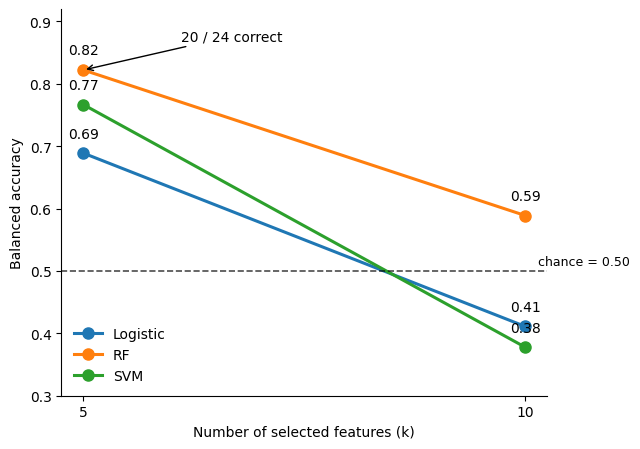

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

cls_plot = pd.DataFrame({
    "model": [
        "RF", "RF",
        "SVM", "SVM",
        "Logistic", "Logistic"
    ],
    "k": [
        5, 10,
        5, 10,
        5, 10
    ],
    "bacc": [
        0.8222, 0.5889,
        0.7667, 0.3778,
        0.6889, 0.4111
    ]
})

fig, ax = plt.subplots(figsize=(6.5, 4.6))

for model, g in cls_plot.groupby("model"):
    g = g.sort_values("k")

    ax.plot(
        g["k"],
        g["bacc"],
        marker="o",
        markersize=8,
        linewidth=2.2,
        label=model
    )

    # 标数值
    for _, row in g.iterrows():
        ax.text(
            row["k"],
            row["bacc"] + 0.025,
            f'{row["bacc"]:.2f}',
            ha="center",
            fontsize=10
        )

# 二分类 chance baseline
ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    color="black",
    alpha=0.7
)

ax.text(
    10.15,
    0.505,
    "chance = 0.50",
    fontsize=9,
    va="bottom"
)

# 强调最好的结果
ax.annotate(
    "20 / 24 correct",
    xy=(5, 0.8222),
    xytext=(6.1, 0.87),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1
    ),
    fontsize=10
)

ax.set_xticks([5, 10])
ax.set_xlabel("Number of selected features (k)")
ax.set_ylabel("Balanced accuracy")

ax.set_ylim(0.30, 0.92)

ax.set_title(
    "",
    loc="left",
    fontsize=13,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    loc="lower left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "classification_k_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

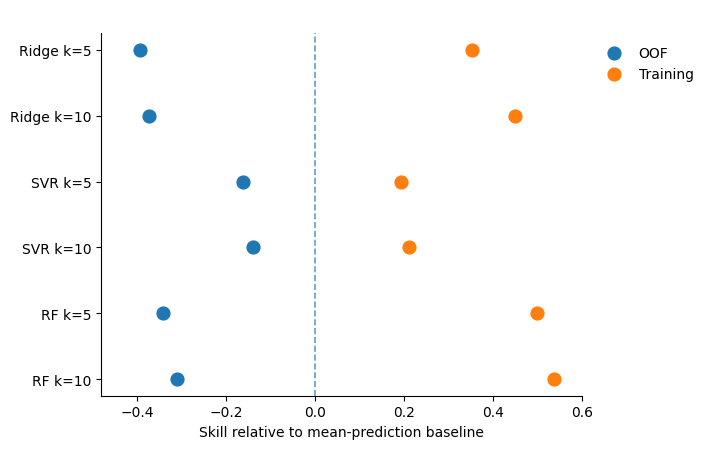

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

reg_plot = pd.DataFrame({
    "config": [
        "Ridge k=5",
        "Ridge k=10",
        "SVR k=5",
        "SVR k=10",
        "RF k=5",
        "RF k=10",
    ],
    "train_skill": [
        0.3529,
        0.4487,
        0.1931,
        0.2114,
        0.4979,
        0.5371,
    ],
    "oof_skill": [
        -0.3935,
        -0.3735,
        -0.1619,
        -0.1400,
        -0.3420,
        -0.3105,
    ]
})

y = np.arange(len(reg_plot))

fig, ax = plt.subplots(figsize=(7.2, 4.6))

# OOF
ax.scatter(
    reg_plot["oof_skill"],
    y,
    s=85,
    label="OOF",
    zorder=3
)

# Training
ax.scatter(
    reg_plot["train_skill"],
    y,
    s=85,
    label="Training",
    zorder=3
)

# zero = no improvement over the relevant mean baseline
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

ax.set_yticks(y)
ax.set_yticklabels(reg_plot["config"])
ax.invert_yaxis()

ax.set_xlim(-0.48, 0.60)
ax.set_xlabel("Skill relative to mean-prediction baseline")

ax.set_title(
    " ",
    loc="left",
    fontsize=15,
    fontweight="bold"
)

# 把 legend 移到图外，避免假装成数据点
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()